# Notebook 3 — QLoRA Fine-Tuning with SFTTrainer
Fine-tunes TinyLlama-1.1B on Medical Q&A using LoRA adapters.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/medical_qa_project')

In [3]:
!pip install -q transformers peft trl datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 23.3 MB/s eta 0:00:00


In [4]:
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
import os

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# ── Load splits ──
train_ds = load_from_disk("dataset/train")
val_ds   = load_from_disk("dataset/val")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 800 | Val: 100


In [5]:
# ── Load tokenizer & model ──
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config.use_cache = False
print("Model loaded.")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded.


In [6]:
# ── Apply LoRA ──
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [7]:
# ── Training arguments ──
training_args = TrainingArguments(
    output_dir="models/checkpoints",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=2,
    learning_rate=2e-4,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=200,
    save_total_limit=2,
    fp16=False,           # set True if using GPU with fp16 support
    report_to="none",
    load_best_model_at_end=True
)

In [12]:
import os
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer

# ── SFTTrainer ──
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

print("Starting training...")
trainer.train()
print("Training complete.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting training...


Step,Training Loss,Validation Loss
100,0.120444,0.136711
200,0.130000,0.132471
300,0.125806,0.132373
400,0.125400,0.130394
500,0.115082,0.130218
600,0.119835,0.129321
700,0.138400,0.128756
800,0.133522,0.128567


Training complete.


In [13]:
# ── Save fine-tuned model ──
os.makedirs("models/final_model", exist_ok=True)
model.save_pretrained("models/final_model")
tokenizer.save_pretrained("models/final_model")
print("Model saved to models/final_model")

Model saved to models/final_model


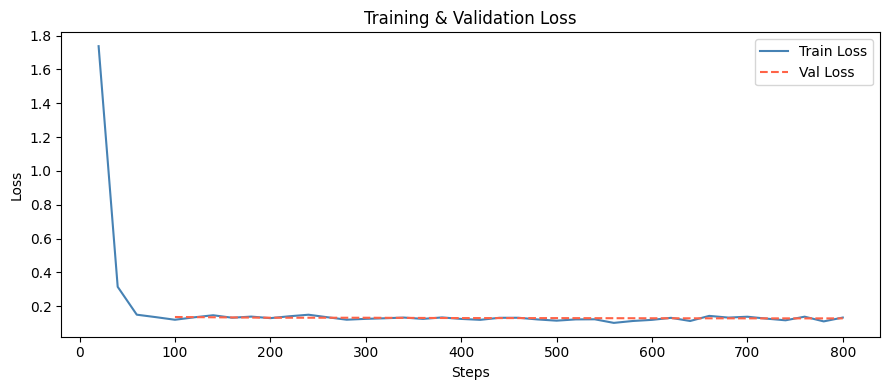

Loss curve saved.


In [15]:
# ── Plot loss curve ──
import matplotlib.pyplot as plt
import os

logs = trainer.state.log_history
train_loss = [(l["step"], l["loss"]) for l in logs if "loss" in l]
eval_loss  = [(l["step"], l["eval_loss"]) for l in logs if "eval_loss" in l]

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(*zip(*train_loss), label="Train Loss", color="steelblue")
if eval_loss:
    ax.plot(*zip(*eval_loss), label="Val Loss", color="tomato", linestyle="--")
ax.set_xlabel("Steps"); ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend(); plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved.")